In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, GlobalAveragePooling2D, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
import pymongo
import os
from tensorflow.keras.utils import Sequence, to_categorical
import gc  # Garbage Collector
import random
from tqdm import tqdm  # Fortschrittsbalken
import tensorflow.keras.backend as K

# Funktion zur Verarbeitung der Bilder in RGB
def process_image_rgb(base64_str, target_size=(224, 224)):
    try:
        image_data = base64.b64decode(base64_str)
        image = Image.open(io.BytesIO(image_data)).convert('RGB')  # Konvertiere Bild zu RGB
        image = image.resize(target_size)
        image_array = np.array(image) / 255.0  # Normalisierung auf Werte zwischen 0 und 1
        return image_array
    except Exception as e:
        print(f"Fehler bei der Bildverarbeitung: {e}")
        return None

def extract_images_from_df(df):
    images = []
    labels = []
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Lade Bilder"):
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            images.append(image)
            labels.append(1 if row['username'] == example_user_id else 0)
    return np.array(images), np.array(labels)

2024-11-13 13:45:52.470115: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-13 13:45:52.493048: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-13 13:45:52.798015: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Datenbankverbindung und Datenladung
def load_data():
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()
    
    # Daten laden
    canvassamples = list(db['canvassamples'].find())
    fingerprints = list(db['fingerprints'].find())
    
    # In DataFrames konvertieren
    canvassamples_df = pd.DataFrame(canvassamples)
    fingerprints_df = pd.DataFrame(fingerprints)
    
    # Merge der DataFrames
    merged_df = pd.merge(canvassamples_df, fingerprints_df, 
                        left_on='fingerprintId', 
                        right_on='_id', 
                        suffixes=('_sample', '_fingerprint'))
    
    return merged_df

# Daten laden
merged_df = load_data()
print(f"Gesamtdatensatz enthält {len(merged_df)} Einträge.")

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

Gesamtdatensatz enthält 2000000 Einträge.
Erste 5 Zeilen für Benutzer benutzername_1:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
0,66e326e9fab6918841db55df,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.906,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
1,66e326e9fab6918841db55db,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.847,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
2,66e326e9fab6918841db55d6,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.772,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
3,66e326e9fab6918841db55e3,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:45.981,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0
4,66e326eafab6918841db55eb,66e326e8fab6918841db55d1,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-09-12 17:37:46.118,0,66e326e8fab6918841db55d1,"{""UserAgent"":""Mozilla/5.0 (Windows NT 10.0; Wi...",609903dc45201305b1c661643326d37bacd216f3c4fe13...,benutzername_1,Benutzer 1,ThinkPad E14 Gen 5,Windows 11,100000,2024-09-12 17:37:44.458,0


Erste 5 Zeilen für Benutzer benutzername_3:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
100000,6703f8369717b7a0d179d6e3,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.318,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100001,6703f8369717b7a0d179d6e7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.339,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100002,6703f8369717b7a0d179d6eb,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.359,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100003,6703f8369717b7a0d179d6ef,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.379,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0
100004,6703f8369717b7a0d179d6f7,6703f8339717b7a0d179d6df,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-07 15:03:18.412,0,6703f8339717b7a0d179d6df,"{""UserAgent"":""Mozilla/5.0 (iPhone; CPU iPhone ...",0bfc7806ac7a11fd13a1a7cb8a309468179bf64f711eb3...,benutzername_3,Benutzer 3,iPhone 11,IOS 17.5.1,100000,2024-10-07 15:03:15.273,0


Erste 5 Zeilen für Benutzer benutzername_4:


...

,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1700000,6707bdebffc8085dd61d7c85,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.742,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700001,6707bdebffc8085dd61d7c8d,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.756,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700002,6707bdebffc8085dd61d7c99,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.773,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700003,6707bdebffc8085dd61d7ca1,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.787,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0
1700004,6707bdebffc8085dd61d7ca9,6707bdeaffc8085dd61d7b38,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 11:43:39.803,0,6707bdeaffc8085dd61d7b38,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",27219c9b5b26960ed3ab916c4fa57a1d5980a7c011581f...,benutzername_20,Benutzer 20,Mac Mini 2016,Sonoma 14.3.1,100000,2024-10-10 11:43:38.104,0


Erste 5 Zeilen für Benutzer benutzername_21:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1800000,6707c487ffc8085dd625a040,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.494,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800001,6707c487ffc8085dd625a044,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.506,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800002,6707c487ffc8085dd625a048,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.517,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800003,6707c487ffc8085dd625a04c,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.528,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0
1800004,6707c487ffc8085dd625a050,6707c486ffc8085dd625a03b,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:11:51.539,0,6707c486ffc8085dd625a03b,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",ceb06c001f5b9b3b7a6ac3c7e77def777ae8b9c977a4f6...,benutzername_21,Benutzer 21,MacMini M1 2020,Ventura 13.2,100000,2024-10-10 12:11:50.062,0


Erste 5 Zeilen für Benutzer benutzername_22:


,_id_sample,fingerprintId,sampleData,createdAt_sample,__v_sample,_id_fingerprint,fingerprint,fingerprintHash,username,name,deviceName,operatingSystem,canvasSampleCount,createdAt_fingerprint,__v_fingerprint
1900000,6707cabdffc8085dd62a72c5,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.957,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900001,6707cabdffc8085dd62a72d1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.970,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900002,6707cabdffc8085dd62a72ca,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.964,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900003,6707cabdffc8085dd62a72dd,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.981,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0
1900004,6707cabdffc8085dd62a72e1,6707cabaffc8085dd62a6eb2,iVBORw0KGgoAAAANSUhEUgAAARgAAAAjCAYAAABPRBVWAA...,2024-10-10 12:38:21.985,0,6707cabaffc8085dd62a6eb2,"{""UserAgent"":""Mozilla/5.0 (Macintosh; Intel Ma...",7c57994e6cde8672f73c095d7d838960776641b9ac240b...,benutzername_22,Benutzer 22,M2 mac mini,macOS Sequoia 15.0,100000,2024-10-10 12:38:18.801,0


In [ ]:
# Funktion zur Auswahl zufälliger Samples von verschiedenen Benutzern
def get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=10):
    selected_users = random.sample([user_id for user_id in user_dfs.keys() if user_id != example_user_id], num_users)
    samples = []
    labels = []
    user_labels = []
    
    for user_id in selected_users:
        user_samples = user_dfs[user_id].sample(n=num_samples_per_user, random_state=42)
        for _, row in user_samples.iterrows():
            image = process_image_rgb(row['sampleData'])
            if image is not None:
                samples.append(image)
                labels.append(0)  # Negative Beispiel
                user_labels.append(user_id)
    
    # Füge positive Beispiele hinzu
    user_samples = user_dfs[example_user_id].sample(n=num_samples_per_user, random_state=42)
    for _, row in user_samples.iterrows():
        image = process_image_rgb(row['sampleData'])
        if image is not None:
            samples.append(image)
            labels.append(1)  # Positive Beispiel
            user_labels.append(example_user_id)
    
    return np.array(samples), np.array(labels), user_labels

# Funktion zur Durchführung der Analyse
def analyze_model(model, user_dfs, example_user_id, iterations=15, num_users=5, num_samples_per_user=10):
    all_results = []
    
    for i in range(iterations):
        X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users, num_samples_per_user)
        y_pred = model.predict(X_samples)
        y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
        
        # Textuelle Analyse
        print(f"Iteration {i+1}")
        print(classification_report(y_samples, y_pred_classes))
        
        all_results.append((y_samples, y_pred_classes, user_labels))
    
    return all_results

# Funktion zur grafischen Darstellung der Benutzerklassifikationen für alle Iterationen
def plot_user_classifications_all_iterations(results, example_user_id):
    combined_df = pd.DataFrame()
    
    for i, (y_samples, y_pred_classes, user_labels) in enumerate(results):
        df = pd.DataFrame({'User': user_labels, 'True Label': y_samples, 'Predicted Label': y_pred_classes})
        df['Correct'] = df['True Label'] == df['Predicted Label']
        df['Iteration'] = i + 1
        combined_df = pd.concat([combined_df, df], ignore_index=True)
    
    # Kreisdiagramme für jede Iteration
    for i in range(1, 16):
        iteration_df = combined_df[combined_df['Iteration'] == i]
        correct_count = iteration_df['Correct'].sum()
        incorrect_count = len(iteration_df) - correct_count
        
        plt.figure(figsize=(8, 8))
        plt.pie([correct_count, incorrect_count], labels=['Correct', 'Incorrect'], autopct='%1.1f%%', colors=['green', 'red'])
        plt.title(f'Iteration {i}: Correct vs Incorrect Predictions')
        plt.show()
    
    # Zusammenfassende grafische Darstellung
    plt.figure(figsize=(14, 8))
    sns.countplot(data=combined_df, x='User', hue='Correct', palette={True: 'green', False: 'red'}, dodge=True)
    plt.title('User Classification Results Across All Iterations')
    plt.xlabel('User')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Correct Prediction')
    plt.show()

: 

Experiment 1/10


Lade Bilder: 100%|██████████| 1493/1493 [00:01<00:00, 1430.53it/s]
2024-11-13 13:46:25.476956: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-13 13:46:25.477062: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-11-13 13:46:25.491925: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https:/

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 model (Functional)          (None, 128)                  2384998   ['input_2[0][0]',             
                                                          4          'input_3[0][0]']             
                                                                                                  
 lambda (Lambda)             (None, 128)                  0         ['model[0][0]',         

2024-11-13 13:46:42.641632: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2024-11-13 13:46:43.344958: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2024-11-13 13:46:43.352506: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x798a89768400 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-11-13 13:46:43.352520: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2024-11-13 13:46:43.352523: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (1): NVIDIA RTX A6000, Compute Capability 8.6
2024-11-13 13:46:43.354599: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-11-13 13:46:43.40652

327/327 [==============================] - 76s 189ms/step - loss: 0.2649 - accuracy: 0.9153 - val_loss: 0.6920 - val_accuracy: 0.5288
Epoch 2/50
327/327 [==============================] - 56s 172ms/step - loss: 0.2369 - accuracy: 0.9252 - val_loss: 0.6915 - val_accuracy: 0.5288
Epoch 3/50
327/327 [==============================] - 56s 172ms/step - loss: 0.2336 - accuracy: 0.9254 - val_loss: 0.6917 - val_accuracy: 0.5288
Epoch 4/50
327/327 [==============================] - 56s 173ms/step - loss: 0.2366 - accuracy: 0.9238 - val_loss: 0.6926 - val_accuracy: 0.5288
Epoch 5/50
327/327 [==============================] - 56s 172ms/step - loss: 0.2283 - accuracy: 0.9269 - val_loss: 0.6936 - val_accuracy: 0.5288
Epoch 6/50
327/327 [==============================] - 56s 172ms/step - loss: 0.2348 - accuracy: 0.9233 - val_loss: 0.6952 - val_accuracy: 0.5288
Epoch 7/50
327/327 [==============================] - 56s 172ms/step - loss: 0.2306 - accuracy: 0.9264 - val_loss: 0.6975 - val_accuracy: 0.5

/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


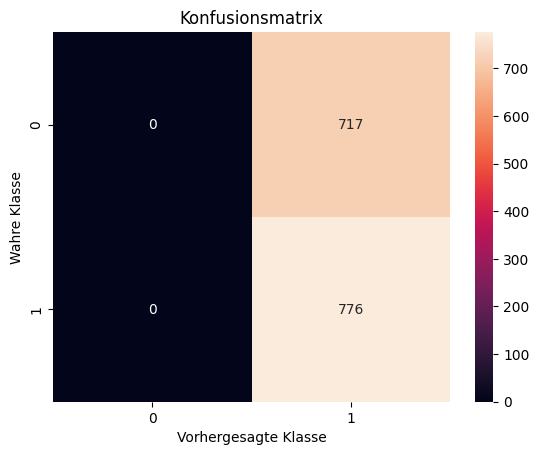

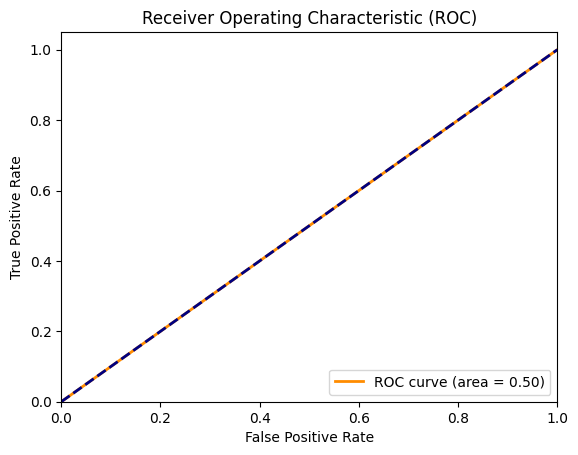

/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modell gespeichert unter: Modelle/Siamese/siamese_model_experiment_1.h5
Experiment 2/10


Lade Bilder: 100%|██████████| 1800/1800 [00:00<00:00, 2069.87it/s]


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_5 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 input_6 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 model_2 (Functional)        (None, 128)                  2384998   ['input_5[0][0]',             
                                                          4          'input_6[0][0]']             
                                                                                                  
 lambda_1 (Lambda)           (None, 128)                  0         ['model_2[0][0]',       

: 

: 

In [4]:
from tensorflow.keras.applications import ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
import os
from tensorflow.keras.utils import plot_model
import pydot
import graphviz
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import gc
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda

# Funktion zur Erstellung des Siamese Netzwerks
def create_siamese_network(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    embedding_model = Model(inputs=base_model.input, outputs=x)
    
    input_a = Input(shape=input_shape)
    input_b = Input(shape=input_shape)
    
    embedding_a = embedding_model(input_a)
    embedding_b = embedding_model(input_b)
    
    l1_distance = Lambda(lambda tensors: K.abs(tensors[0] - tensors[1]))([embedding_a, embedding_b])
    
    output = Dense(1, activation='sigmoid')(l1_distance)
    
    siamese_model = Model(inputs=[input_a, input_b], outputs=output)
    
    return siamese_model

# Funktion zur Erstellung und Evaluierung von Modellen
def create_and_evaluate_models(user_dfs, example_user_id, num_experiments=1):
    experiment_results = []
    model_dir = "Modelle/Siamese"
    os.makedirs(model_dir, exist_ok=True)
    
    for exp_num in range(num_experiments):
        print(f"Experiment {exp_num + 1}/{num_experiments}")
        
        num_positive_samples = random.randint(5000, 10000)
        num_negative_samples = random.randint(5000, 10000)
        
        user_df = user_dfs[example_user_id].sample(n=num_positive_samples, random_state=42)
        
        negative_df = pd.concat([user_dfs[user_id] for user_id in user_ids if user_id != example_user_id])
        negative_df = negative_df.sample(n=num_negative_samples, random_state=42)
        
        train_df, test_df = train_test_split(pd.concat([user_df, negative_df]), test_size=0.1, random_state=42)
        train_df, val_df = train_test_split(train_df, test_size=0.2222, random_state=42)
        
        try:
            X_train, y_train = extract_images_from_df(train_df)
            X_val, y_val = extract_images_from_df(val_df)
            X_test, y_test = extract_images_from_df(test_df)
        except Exception as e:
            print(f"Fehler bei der Bilddatenverarbeitung: {e}")
            continue
        
        gc.collect()
        
        model_name = f"siamese_model_experiment_{exp_num + 1}"
        
        input_shape = (224, 224, 3)
        model = create_siamese_network(input_shape)
        
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        
        model.summary()
        
        plot_model(model, to_file=os.path.join(model_dir, f"{model_name}_architecture.png"), show_shapes=True)
        
        try:
            history = model.fit([X_train, X_train], y_train, epochs=50, validation_data=([X_val, X_val], y_val))
        except Exception as e:
            print(f"Fehler beim Training des Modells: {e}")
            continue
        
        try:
            loss, accuracy = model.evaluate([X_test, X_test], y_test)
            print(f"Test Loss: {loss}")
            print(f"Test Accuracy: {accuracy}")
        except Exception as e:
            print(f"Fehler bei der Modellbewertung: {e}")
            continue
        
        try:
            y_pred = model.predict([X_test, X_test])
            y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
            y_true = y_test
            
            print(classification_report(y_true, y_pred_classes))
            
            conf_matrix = confusion_matrix(y_true, y_pred_classes)
            sns.heatmap(conf_matrix, annot=True, fmt='d')
            plt.title('Konfusionsmatrix')
            plt.xlabel('Vorhergesagte Klasse')
            plt.ylabel('Wahre Klasse')
            plt.show()
            
            fpr, tpr, _ = roc_curve(y_true, y_pred)
            roc_auc = auc(fpr, tpr)
            plt.figure()
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Receiver Operating Characteristic (ROC)')
            plt.legend(loc="lower right")
            plt.show()
            
            model_path = os.path.join(model_dir, f"{model_name}.h5")
            model.save(model_path)
            print(f"Modell gespeichert unter: {model_path}")
            
            experiment_results.append({
                'experiment': exp_num + 1,
                'model_name': model_name,
                'num_positive_samples': num_positive_samples,
                'num_negative_samples': num_negative_samples,
                'accuracy': accuracy,
                'roc_auc': roc_auc
            })
        except Exception as e:
            print(f"Fehler bei der Vorhersage und Auswertung: {e}")
            continue
    
    return experiment_results

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# 10 verschiedene Experimente durchführen und Ergebnisse speichern
experiment_results = create_and_evaluate_models(user_dfs, example_user_id, num_experiments=10)

# Ergebnisse zusammenfassen und vergleichen
results_df = pd.DataFrame(experiment_results)
print(results_df)

# Zusammenfassende grafische Darstellung der Ergebnisse
plt.figure(figsize=(14, 8))
sns.barplot(data=results_df, x='experiment', y='accuracy')
plt.title('Model Accuracy Across Different Experiments')
plt.xlabel('Experiment')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(data=results_df, x='experiment', y='roc_auc')
plt.title('ROC AUC Across Different Experiments')
plt.xlabel('Experiment')
plt.ylabel('ROC AUC')
plt.show()

Lade Modell: Modelle/CNN_Negative/model_experiment_2_ResNet.h5
2/2 [==============================] - 0s 22ms/step
Modell: model_experiment_2_ResNet.h5
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


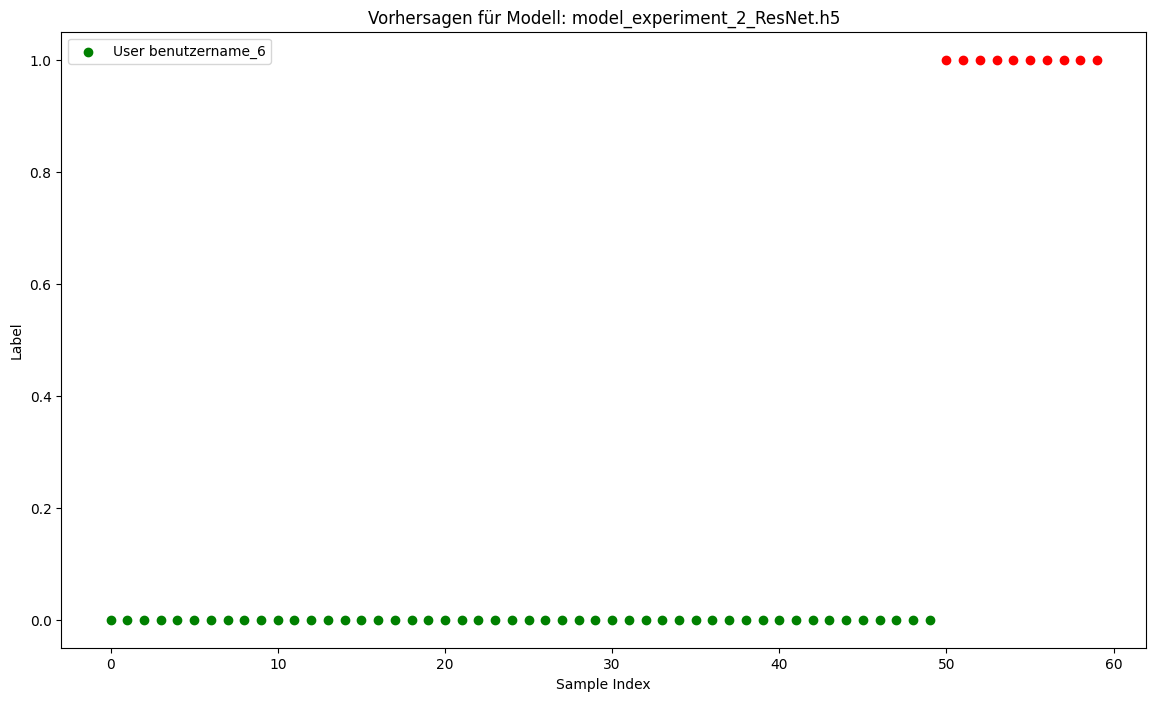

Lade Modell: Modelle/CNN_Negative/model_experiment_3_MobileNetV2.h5
2/2 [==============================] - 0s 14ms/step
Modell: model_experiment_3_MobileNetV2.h5
Accuracy: 0.75
Precision: 0.4
Recall: 1.0
F1 Score: 0.5714285714285715
ROC AUC: 0.902


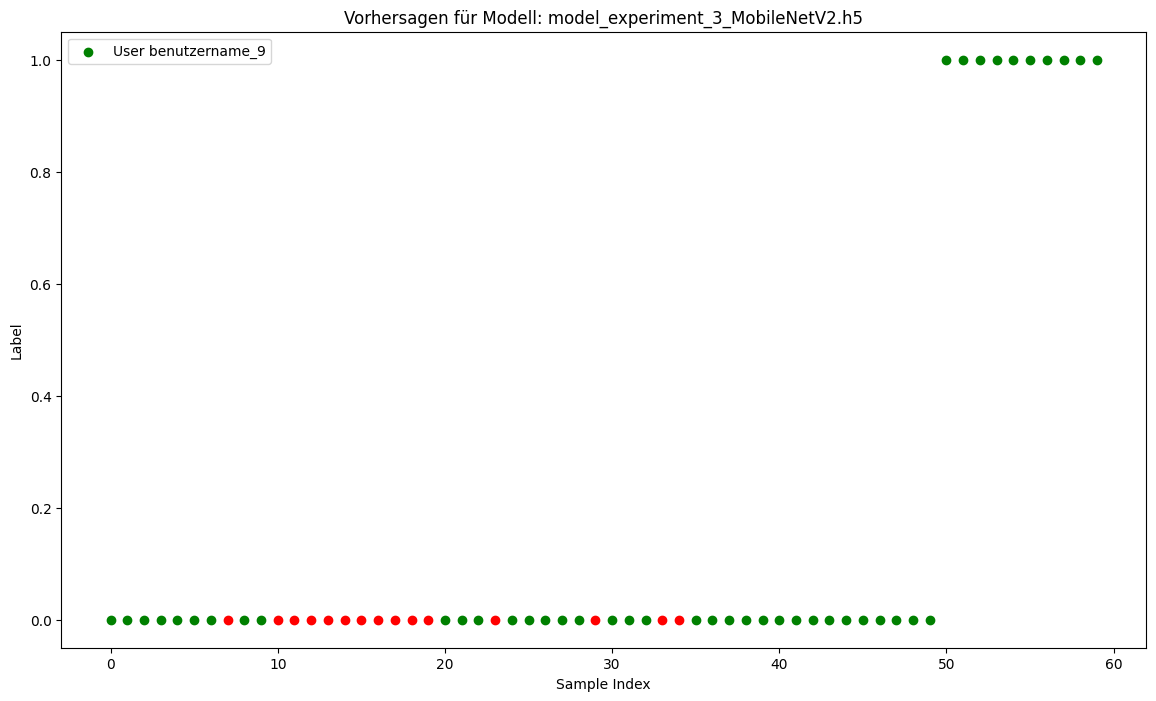

Lade Modell: Modelle/CNN_Negative/model_experiment_7_CNN.h5
2/2 [==============================] - 0s 6ms/step
Modell: model_experiment_7_CNN.h5
Accuracy: 0.85
Precision: 0.5263157894736842
Recall: 1.0
F1 Score: 0.6896551724137931
ROC AUC: 0.9580000000000001


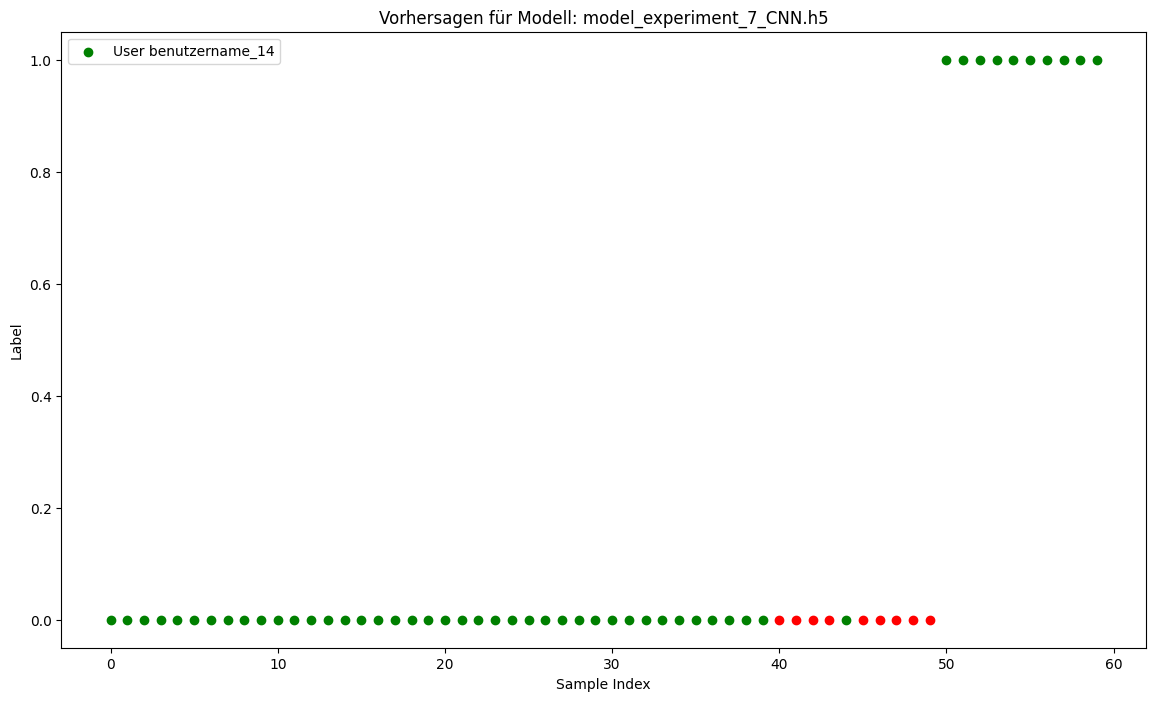

Lade Modell: Modelle/CNN_Negative/model_experiment_1_CNN.h5
2/2 [==============================] - 0s 5ms/step
Modell: model_experiment_1_CNN.h5
Accuracy: 0.6666666666666666
Precision: 0.3333333333333333
Recall: 1.0
F1 Score: 0.5
ROC AUC: 0.914


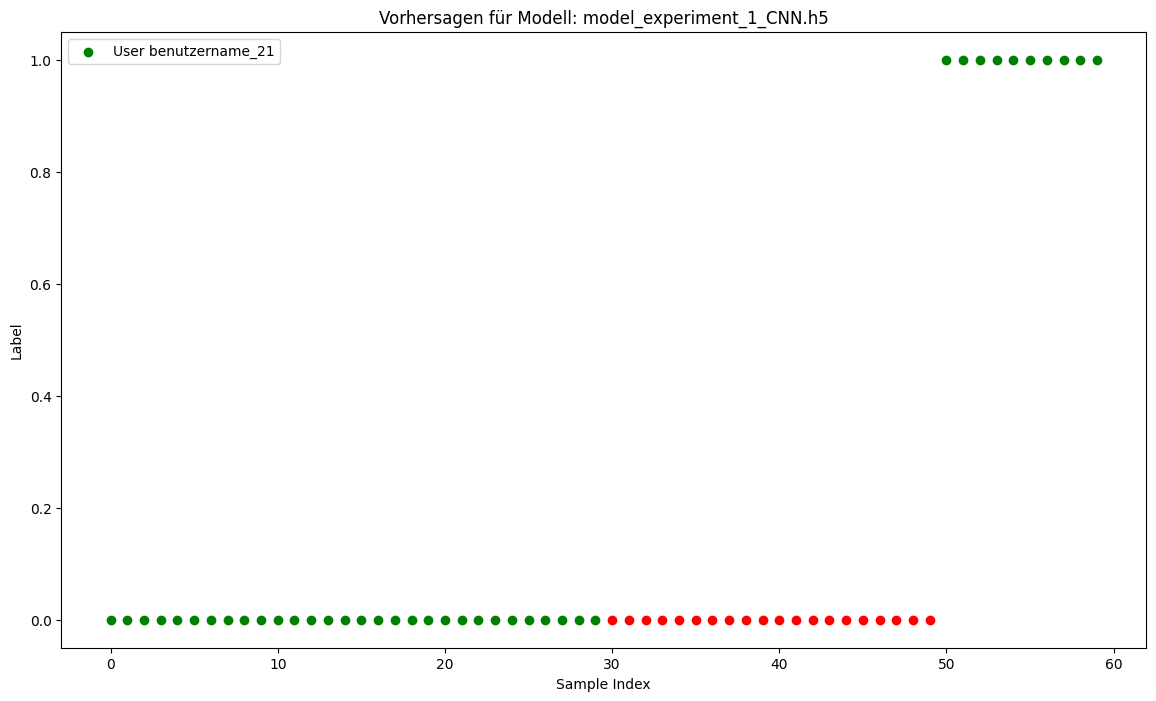

Lade Modell: Modelle/CNN_Negative/model_experiment_4_CNN.h5
2/2 [==============================] - 0s 6ms/step
Modell: model_experiment_4_CNN.h5
Accuracy: 0.6833333333333333
Precision: 0.3333333333333333
Recall: 0.9
F1 Score: 0.48648648648648646
ROC AUC: 0.8520000000000001


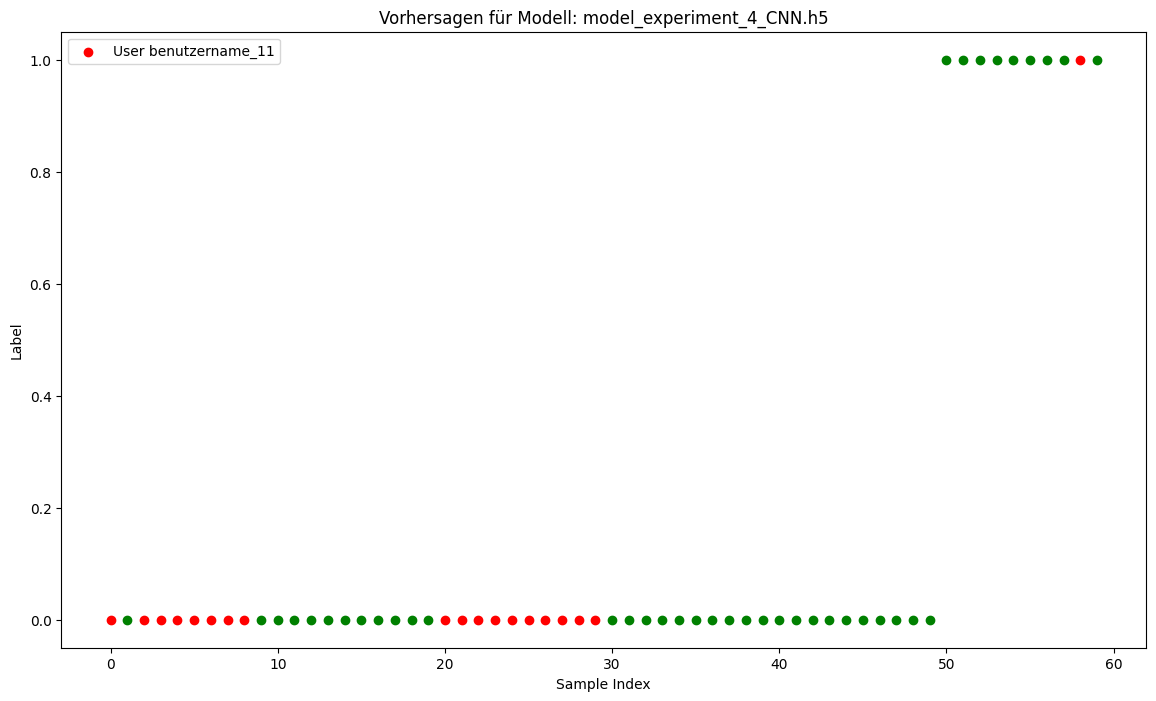

Lade Modell: Modelle/CNN_Negative/model_experiment_6_MobileNetV2.h5
2/2 [==============================] - 0s 13ms/step
Modell: model_experiment_6_MobileNetV2.h5
Accuracy: 0.8166666666666667
Precision: 0.47368421052631576
Recall: 0.9
F1 Score: 0.6206896551724138
ROC AUC: 0.916


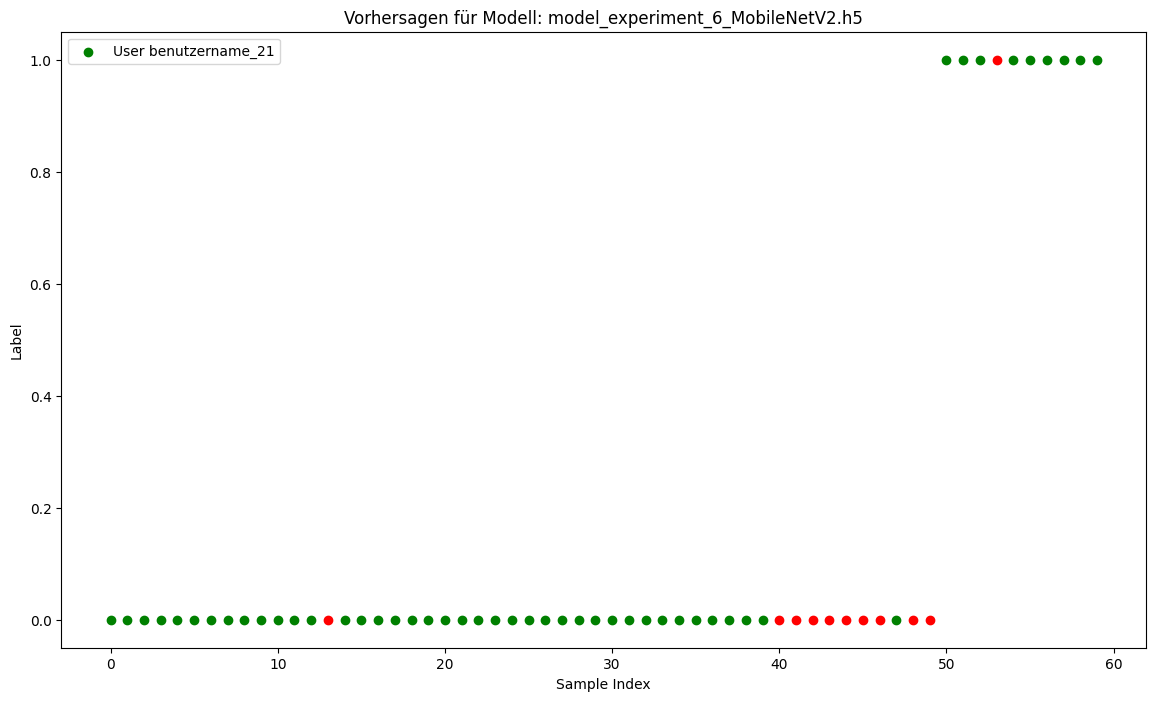

Lade Modell: Modelle/CNN_Negative/model_experiment_8_ResNet.h5
2/2 [==============================] - 0s 23ms/step
Modell: model_experiment_8_ResNet.h5
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


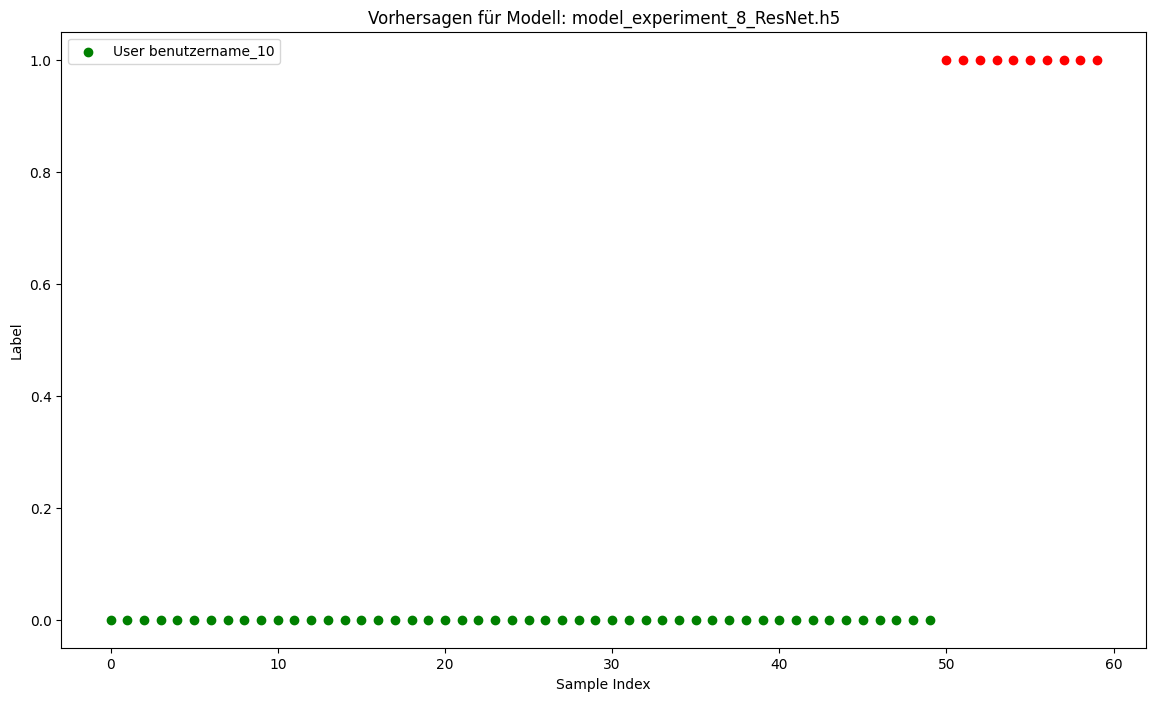

Lade Modell: Modelle/CNN_Negative/model_experiment_10_CNN.h5
2/2 [==============================] - 0s 5ms/step
Modell: model_experiment_10_CNN.h5
Accuracy: 0.85
Precision: 0.5263157894736842
Recall: 1.0
F1 Score: 0.6896551724137931
ROC AUC: 0.9500000000000001


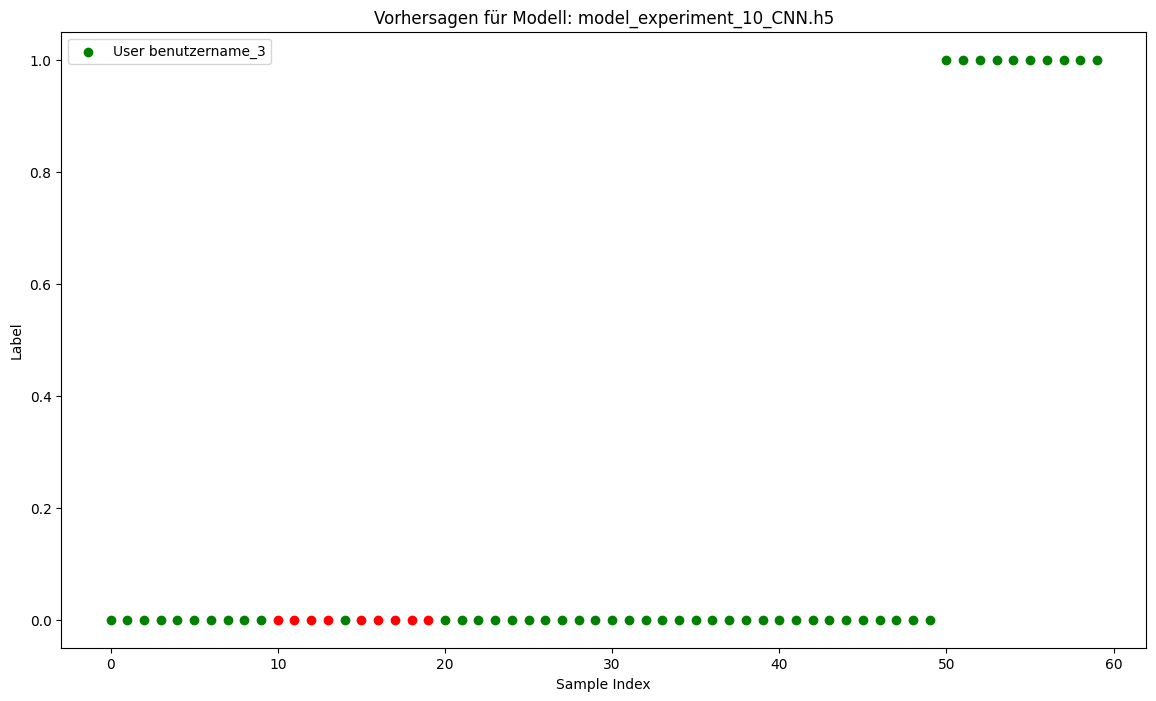

Lade Modell: Modelle/CNN_Negative/model_experiment_9_MobileNetV2.h5
2/2 [==============================] - 0s 12ms/step
Modell: model_experiment_9_MobileNetV2.h5
Accuracy: 0.8166666666666667
Precision: 0.47619047619047616
Recall: 1.0
F1 Score: 0.6451612903225806
ROC AUC: 0.8700000000000001


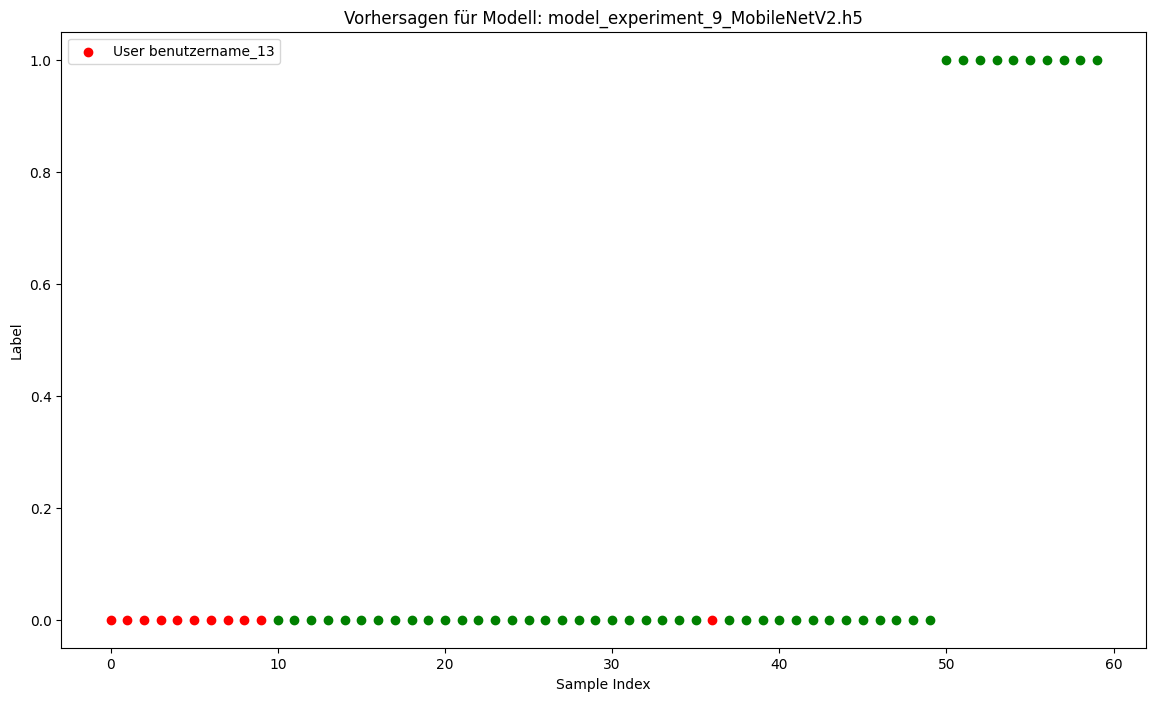

Lade Modell: Modelle/CNN_Negative/model_experiment_5_ResNet.h5
2/2 [==============================] - 0s 21ms/step
Modell: model_experiment_5_ResNet.h5
Accuracy: 0.8333333333333334
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.5


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


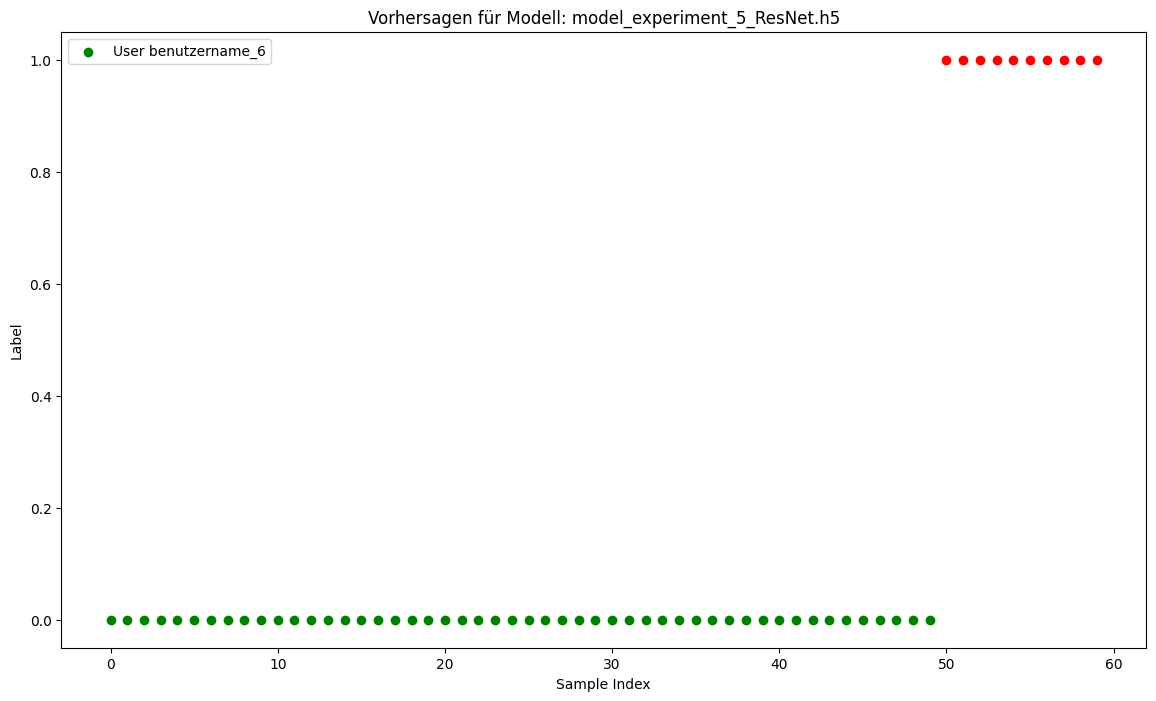

                               model  accuracy  precision  recall  f1_score  \
0       model_experiment_2_ResNet.h5  0.833333   0.000000     0.0  0.000000   
1  model_experiment_3_MobileNetV2.h5  0.750000   0.400000     1.0  0.571429   
2          model_experiment_7_CNN.h5  0.850000   0.526316     1.0  0.689655   
3          model_experiment_1_CNN.h5  0.666667   0.333333     1.0  0.500000   
4          model_experiment_4_CNN.h5  0.683333   0.333333     0.9  0.486486   
5  model_experiment_6_MobileNetV2.h5  0.816667   0.473684     0.9  0.620690   
6       model_experiment_8_ResNet.h5  0.833333   0.000000     0.0  0.000000   
7         model_experiment_10_CNN.h5  0.850000   0.526316     1.0  0.689655   
8  model_experiment_9_MobileNetV2.h5  0.816667   0.476190     1.0  0.645161   
9       model_experiment_5_ResNet.h5  0.833333   0.000000     0.0  0.000000   

   roc_auc  
0    0.500  
1    0.902  
2    0.958  
3    0.914  
4    0.852  
5    0.916  
6    0.500  
7    0.950  
8    0.870  


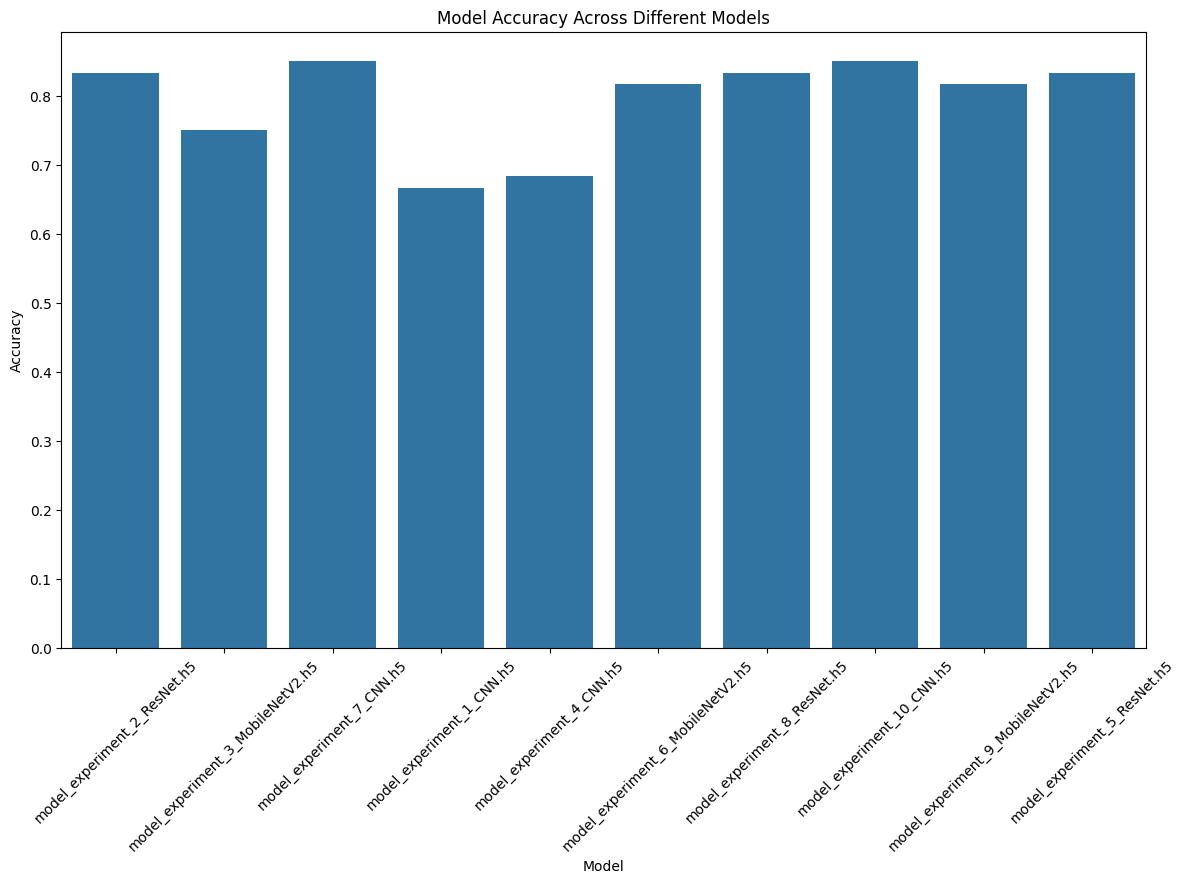

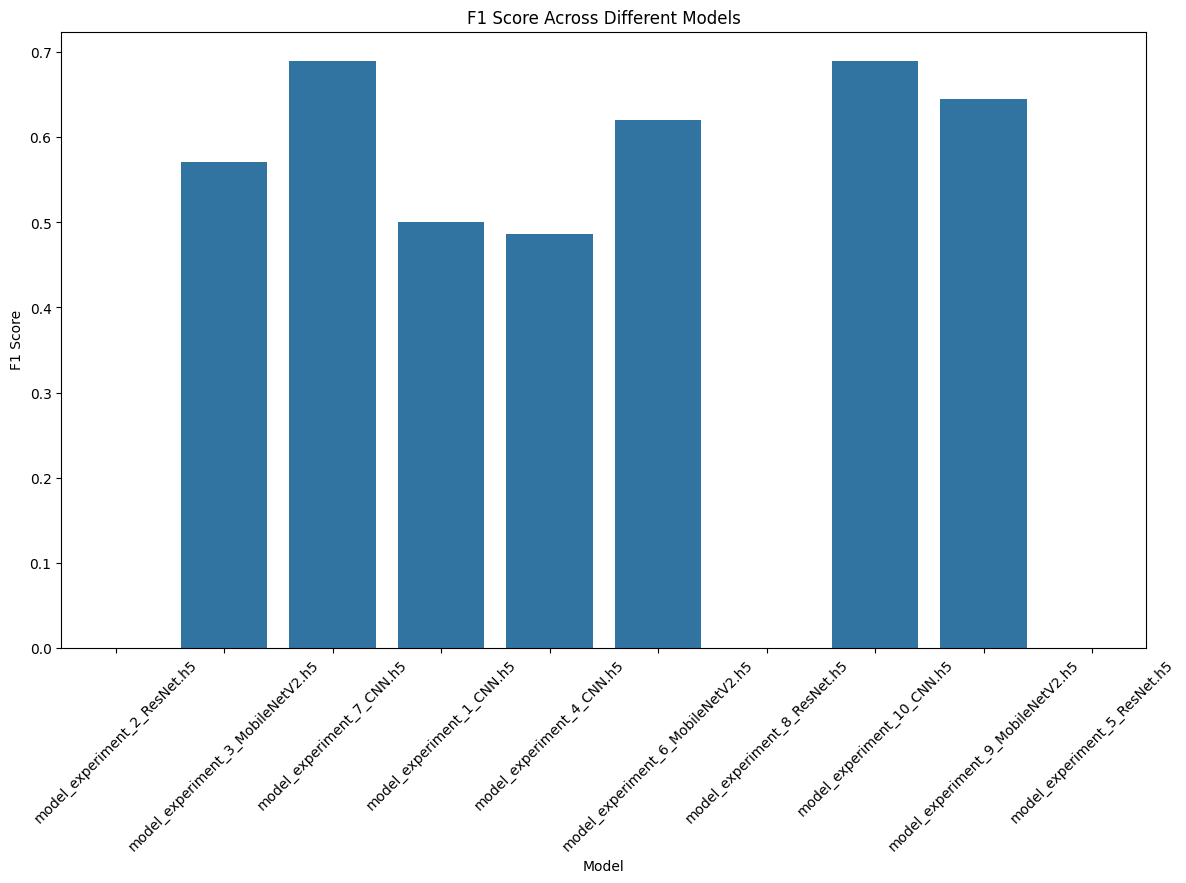

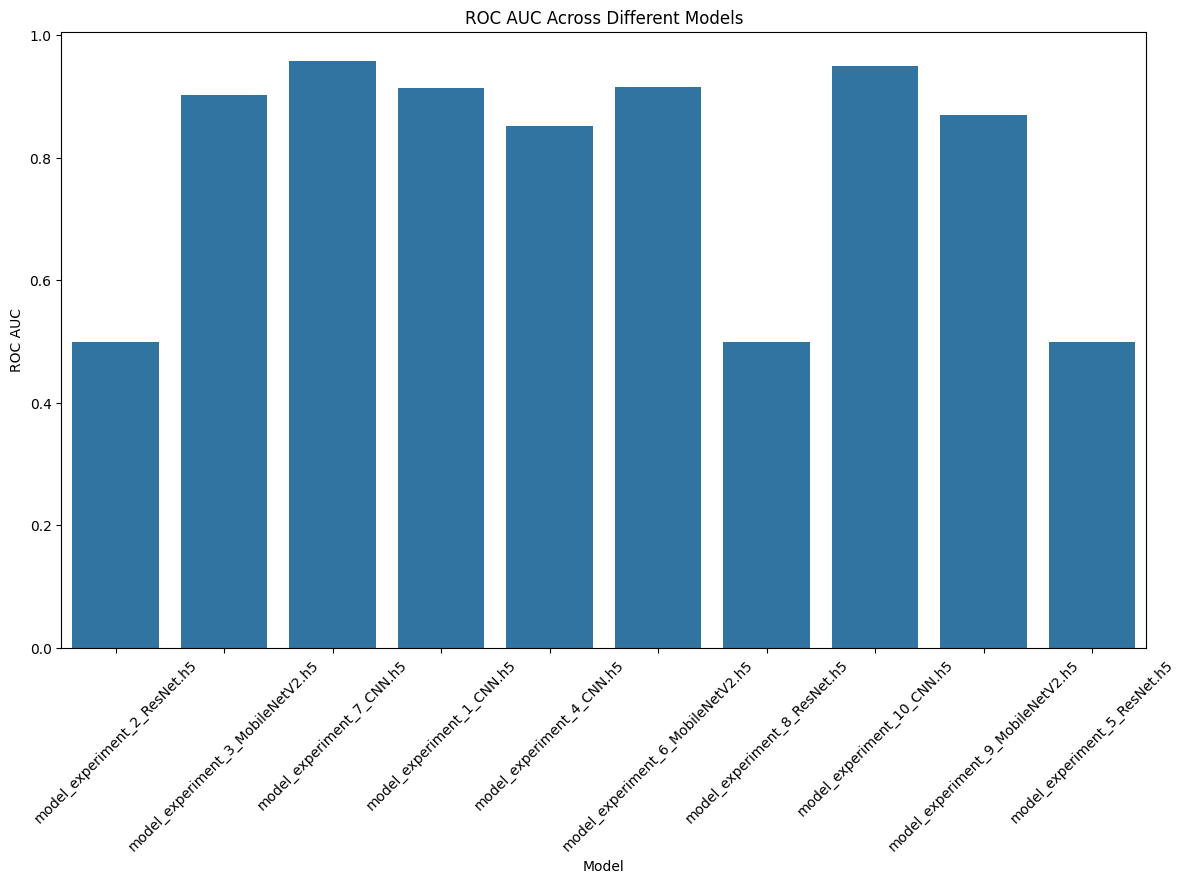

In [ ]:
from tensorflow.keras.models import load_model
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Funktion zum Laden und Testen aller gespeicherten Modelle
def load_and_test_models(model_dir, user_dfs, example_user_id):
    model_files = [f for f in os.listdir(model_dir) if f.endswith('.h5')]
    test_results = []
    
    for model_file in model_files:
        model_path = os.path.join(model_dir, model_file)
        print(f"Lade Modell: {model_path}")
        model = load_model(model_path)
        
        # Testen des Modells mit Samples von anderen Nutzern
        X_samples, y_samples, user_labels = get_random_samples(user_dfs, example_user_id, num_users=5, num_samples_per_user=10)
        y_pred = model.predict(X_samples)
        y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
        
        # Berechnung der Metriken
        accuracy = accuracy_score(y_samples, y_pred_classes)
        precision = precision_score(y_samples, y_pred_classes)
        recall = recall_score(y_samples, y_pred_classes)
        f1 = f1_score(y_samples, y_pred_classes)
        roc_auc = auc(*roc_curve(y_samples, y_pred)[:2])
        
        print(f"Modell: {model_file}")
        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1 Score: {f1}")
        print(f"ROC AUC: {roc_auc}")
        
        test_results.append({
            'model': model_file,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc
        })
        
        # Visualisierung der Vorhersagen
        plt.figure(figsize=(14, 8))
        for i, (true_label, pred_label, user_label) in enumerate(zip(y_samples, y_pred_classes, user_labels)):
            color = 'green' if true_label == pred_label else 'red'
            plt.scatter(i, true_label, color=color, label=f'User {user_label}' if i == 0 else "")
        plt.title(f'Vorhersagen für Modell: {model_file}')
        plt.xlabel('Sample Index')
        plt.ylabel('Label')
        plt.legend()
        plt.show()
    
    return test_results

# Modelle laden und testen
model_dir = "Modelle/CNN_Negative"
test_results = load_and_test_models(model_dir, user_dfs, example_user_id)

# Ergebnisse zusammenfassen und vergleichen
test_results_df = pd.DataFrame(test_results)
print(test_results_df)

# Zusammenfassende grafische Darstellung der Testergebnisse
plt.figure(figsize=(14, 8))
sns.barplot(data=test_results_df, x='model', y='accuracy')
plt.title('Model Accuracy Across Different Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(data=test_results_df, x='model', y='f1_score')
plt.title('F1 Score Across Different Models')
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(14, 8))
sns.barplot(data=test_results_df, x='model', y='roc_auc')
plt.title('ROC AUC Across Different Models')
plt.xlabel('Model')
plt.ylabel('ROC AUC')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from tensorflow.keras.models import load_model
import os

# Verzeichnis der gespeicherten Modelle
model_dir = "Modelle/Siamese"

# Liste der Modell-Dateien
model_files = [f for f in os.listdir(model_dir) if f.endswith('.h5')]

# Beispiel für Benutzer 1
example_user_id = 'benutzername_1'

# Analyse der gespeicherten Modelle
for model_file in model_files:
    model_path = os.path.join(model_dir, model_file)
    print(f"Lade Modell: {model_path}")
    model = load_model(model_path)
    
    # Analyse durchführen
    results = analyze_model(model, user_dfs, example_user_id, iterations=10)
    
    # Grafische Darstellung der Benutzerklassifikationen für alle Iterationen
    plot_user_classifications_all_iterations(results, example_user_id)

NameError: name 'model' is not defined